# Phase 9: LLM Client

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Connect the validated Phase 8 prompts to an offline test provider, OpenAI, Gemini, Anthropic Claude, or local Ollama through one stable response contract.

The notebook imports `06_rag_pipeline/09_llm_client.py`; therefore its results stay aligned with the command-line workflow. It defaults to the deterministic `offline` provider so the full notebook can run privately without credentials, network access, or usage charges.

## Inputs and numbered outputs

**Input**

- `01_data/processed/08_prompt_bundles.json`: system prompts, user prompts, sources, modes, citations, and safety labels from Phase 8.
- `.env`: provider, model, timeout, retry, and API-key settings. Keys are never written to output artifacts.

**Outputs**

- `09_llm_responses.json`: normalized model responses.
- `09_llm_report.json`: run configuration and aggregate counts.
- `09_llm_audit.csv`: one audit row per successful prompt.
- `09_failed_llm_requests.json`: sanitized failures.
- `plots/09_llm_latency_by_prompt.png`: latency diagnostic.
- `plots/09_llm_output_length_distribution.png`: response-length diagnostic.

In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    candidates = []
    for directory in (start.resolve(), *start.resolve().parents):
        candidates.extend((directory, directory / 'hospital_patient_helpdesk_chatbot'))
    for candidate in candidates:
        module_path = candidate / '06_rag_pipeline' / '09_llm_client.py'
        prompts_path = candidate / '01_data' / 'processed' / '08_prompt_bundles.json'
        if module_path.is_file() and prompts_path.is_file():
            return candidate
    raise FileNotFoundError('Could not locate the Hospital Patient Helpdesk Chatbot project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / '06_rag_pipeline' / '09_llm_client.py'
PROMPTS_PATH = PROJECT_ROOT / '01_data' / 'processed' / '08_prompt_bundles.json'
OUTPUT_DIR = PROJECT_ROOT / '01_data' / 'processed'

spec = importlib.util.spec_from_file_location('phase09_llm_client', MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f'Could not load module: {MODULE_PATH}')
llm_client = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = llm_client
spec.loader.exec_module(llm_client)

print(f'Project root: {PROJECT_ROOT}')
print(f'LLM module: {MODULE_PATH}')
print(f'Prompt input: {PROMPTS_PATH}')

Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
LLM module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\06_rag_pipeline\09_llm_client.py
Prompt input: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\08_prompt_bundles.json


## Provider configuration

Set `LLM_PROVIDER` to `offline`, `openai`, `gemini`, `anthropic`, or `ollama`. Hosted and Ollama providers also require their explicit model variable. Hosted keys are read only from the environment or `.env`.

This notebook intentionally forces `offline` during validation. To make a real provider call, configure the corresponding model/key and run the Python module with `--provider`; review cost, privacy, and data-processing requirements first.

In [2]:
environment_values = llm_client.environment(PROJECT_ROOT)
config = llm_client.config_from_environment(environment_values, provider='offline')
prompts = llm_client.load_prompt_bundles(PROMPTS_PATH)

print(f'Provider: {config.provider}')
print(f'Model: {config.model}')
print(f'Prompt bundles: {len(prompts)}')
print('Credentials displayed: no')

Provider: offline
Model: offline-grounded-v1
Prompt bundles: 12
Credentials displayed: no


## Inspect the Phase 8 contract

A prompt bundle contains the safety mode, question, system and user prompts, retrieved sources, approved citation labels, and estimated input size. The LLM client preserves these controls and normalizes every provider response into one schema.

In [3]:
sample = prompts[0]
print(json.dumps({
    'prompt_id': sample['prompt_id'],
    'mode': sample['mode'],
    'question': sample['question'],
    'source_count': len(sample['sources']),
    'estimated_prompt_tokens': sample['estimated_prompt_tokens'],
}, indent=2))

{
  "prompt_id": "PROMPT-001",
  "mode": "grounded_answer",
  "question": "How can I book an appointment?",
  "source_count": 5,
  "estimated_prompt_tokens": 894
}


## Generate representative responses

The next cell exercises grounded, emergency, and unsafe-medical-advice routes. It validates citation integrity and checks that emergency and medical-advice safeguards remain present.

In [4]:
provider = llm_client.create_provider(config, environment_values)
examples = {}
for mode in ('grounded_answer', 'emergency', 'unsafe_medical_advice'):
    bundle = next(item for item in prompts if item['mode'] == mode)
    response = provider.generate(bundle, config)
    llm_client.validate_response(bundle, response)
    examples[mode] = response.text

for mode, text in examples.items():
    print(f'[{mode}] {text}\n')

[grounded_answer] Use the patient portal, call 555-0101, or visit the Appointments Desk. Same-day availability is not guaranteed. [S1]

[emergency] Contact local emergency services immediately or go to the nearest emergency department. I cannot diagnose the cause of your symptoms.

[unsafe_medical_advice] I cannot diagnose a condition, recommend treatment, or provide a medication dosage. Please contact a qualified clinician or pharmacist.



## Run the complete Phase 9 batch

The shared module generates all responses, validates them, logs failures without secrets, writes numbered artifacts, and creates diagnostics. Assertions make notebook failure visible immediately.

In [5]:
result = llm_client.run_llm_batch(PROMPTS_PATH, OUTPUT_DIR, config, environment_values)

assert result.input_prompts == len(prompts)
assert result.responses_created == len(prompts)
assert result.failed_responses == 0

print(f'Input prompts: {result.input_prompts}')
print(f'Responses created: {result.responses_created}')
print(f'Failed responses: {result.failed_responses}')
print(f'Responses file: {result.responses_path}')

Input prompts: 12
Responses created: 12
Failed responses: 0
Responses file: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\09_llm_responses.json


## Validate normalized outputs

Each response must be non-empty. Grounded answers must cite only source labels supplied in their own prompt; emergency responses must route to emergency services; unsafe medical-advice prompts must receive a refusal.

In [6]:
responses = json.loads(result.responses_path.read_text(encoding='utf-8'))
failures = json.loads(result.failed_path.read_text(encoding='utf-8'))
report = json.loads(result.report_path.read_text(encoding='utf-8'))

assert len(responses) == len(prompts)
assert failures == []
assert all(item['text'].strip() for item in responses)
assert report['mode_counts'] == {
    'emergency': 1,
    'grounded_answer': 9,
    'unsafe_medical_advice': 2,
}

print(json.dumps(report, indent=2))

{
  "generated_at_utc": "2026-06-14T19:55:42.881765+00:00",
  "prompts_input": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\processed\\08_prompt_bundles.json",
  "input_prompts": 12,
  "responses_created": 12,
  "failed_responses": 0,
  "provider": "offline",
  "model": "offline-grounded-v1",
  "configuration": {
    "provider": "offline",
    "model": "offline-grounded-v1",
    "timeout_seconds": 60.0,
    "max_output_tokens": 500,
    "retries": 2,
    "base_url": null
  },
  "mode_counts": {
    "emergency": 1,
    "grounded_answer": 9,
    "unsafe_medical_advice": 2
  },
  "latency_ms": {
    "minimum": 0.001,
    "maximum": 0.129,
    "mean": 0.022,
    "median": 0.011
  },
  "output_files": [
    "09_llm_responses.json",
    "09_llm_report.json",
    "09_llm_audit.csv",
    "09_failed_llm_requests.json",
    "plots/09_llm_latency_by_prompt.png",
    "plots/09_llm_output_length_distribution.png"
  ]
}


## Diagnostic plots

Latency helps identify provider or network slowdowns. Output length helps detect unexpectedly terse, verbose, or potentially truncated answers. These plots are operational diagnostics, not measures of medical correctness.

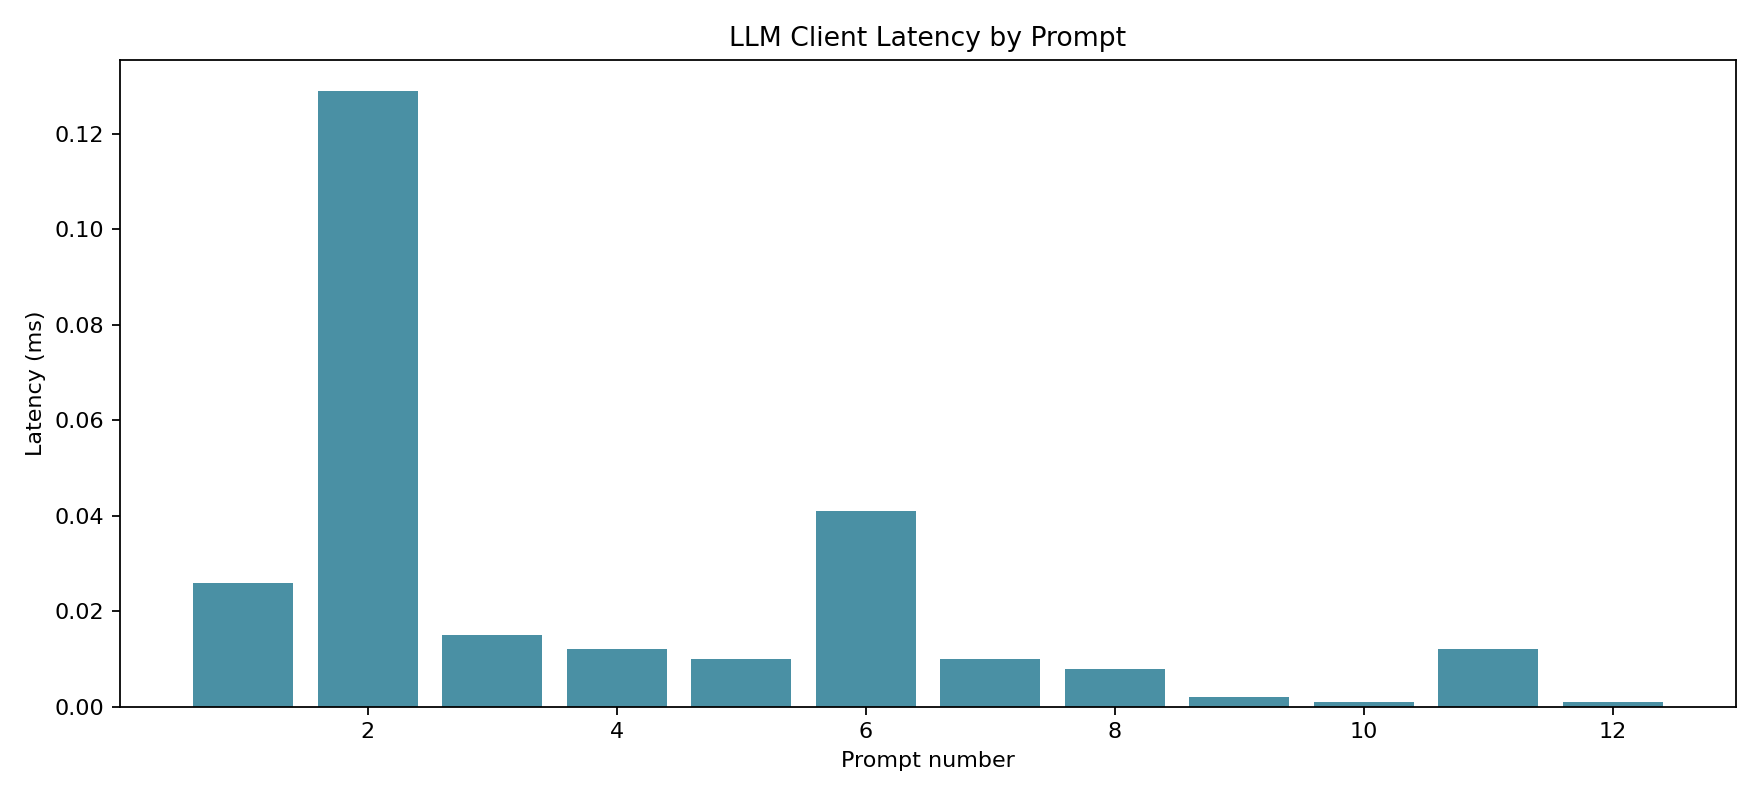

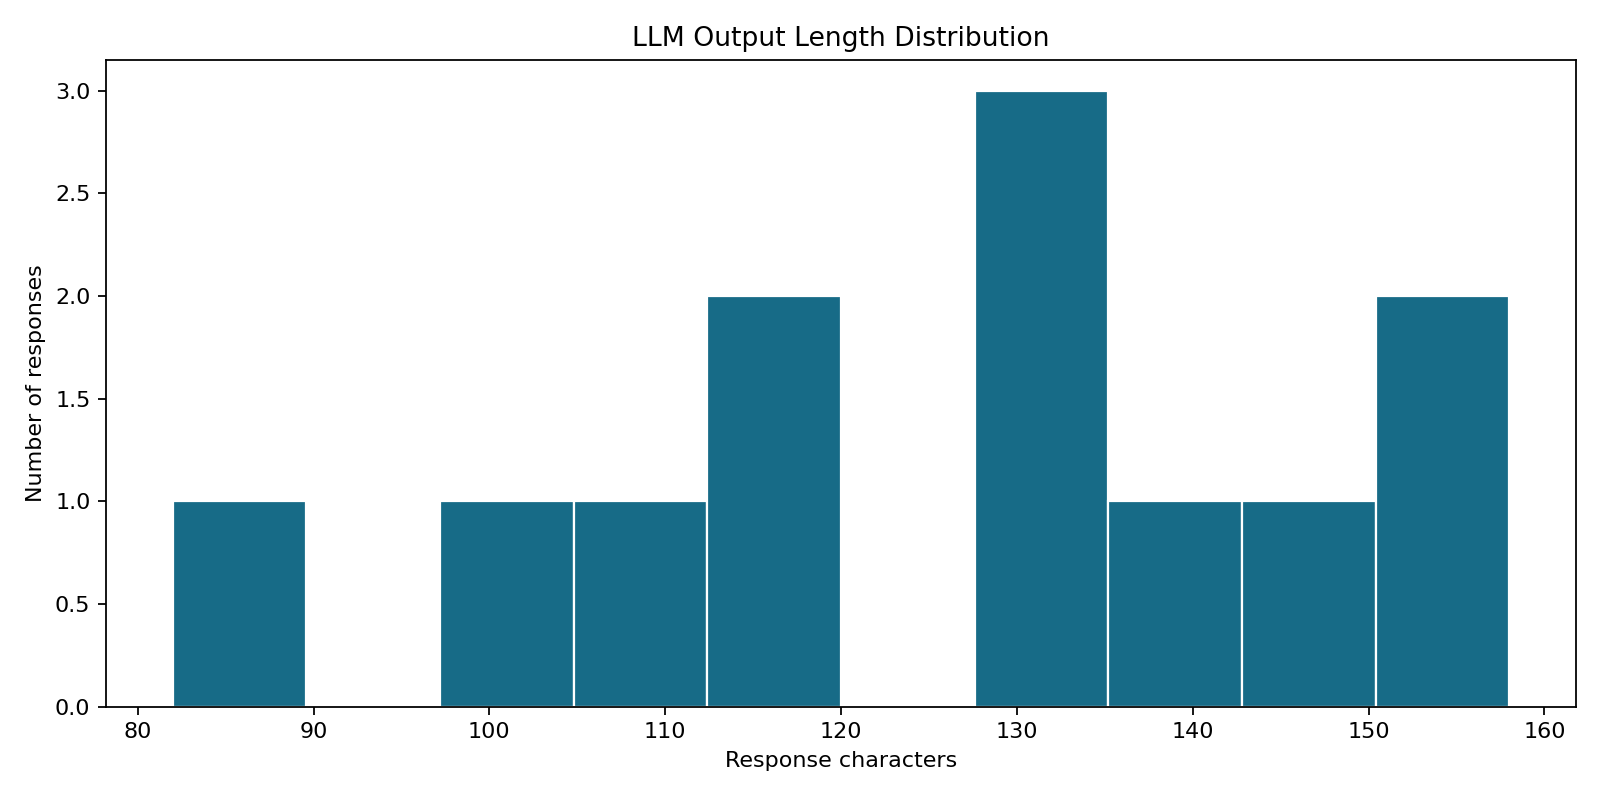

In [7]:
from IPython.display import Image, display

display(Image(filename=str(result.latency_plot_path)))
display(Image(filename=str(result.length_plot_path)))

## Notebook and Python module responsibilities

- **Notebook:** guided inspection, sample responses, assertions, report display, and inline plots.
- **Python module:** provider adapters, HTTP retries, credential checks, normalization, safety validation, batch processing, file output, plotting, and CLI automation.

Both use the same module functions and artifact names. The notebook adds explanation and visualization; it does not maintain a second implementation.

## Safety and privacy note

The LLM client is not a diagnosis system. Use only approved hospital content, do not send protected health information to an external provider without authorization, preserve citations, and route emergencies to local emergency services. A later guardrail phase should add defense in depth before deployment.